In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')


In [8]:
def prepare_model():
    print("Veri seti yükleniyor ve işleniyor...")
    # Veriyi yükle
    df = pd.read_csv('dataset/train.csv')

    # Veri ön izleme
    print("\nVeri Seti Önizleme:")
    print(df.head())

    # Özellik mühendisliği
    df['engine_power'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
    df['engine_volume'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)
    df['cylinders'] = df['engine'].str.extract(r'(\d+) Cylinder').astype(float)
    df['fuel_type'] = df['fuel_type'].str.replace('Gasoline/Mild Electric Hybrid', 'Hybrid')
    df['fuel_type'] = df['fuel_type'].str.replace('Plug-In Electric/Gas', 'Hybrid')
    df['fuel_type'] = df['fuel_type'].str.replace('Gas/Electric Hybrid', 'Hybrid')
    df['age'] = 2023 - df['model_year']
    df['accident'] = df['accident'].apply(lambda x: 1 if 'accident' in str(x) else 0)
    df['clean_title'] = df['clean_title'].apply(lambda x: 1 if str(x) == 'Yes' else 0)
    df['transmission_type'] = df['transmission'].apply(
        lambda x: 'Automatic' if 'A/T' in str(x) else 'Manual' if 'M/T' in str(x) else 'Other')

    # Temizlik
    df = df.dropna(subset=['engine_power', 'engine_volume', 'cylinders'])
    df['clean_title'].fillna(0, inplace=True)

    # Veri dağılımı görselleştirme
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    sns.histplot(df['price'], bins=30, kde=True)
    plt.title('Fiyat Dağılımı')

    plt.subplot(2, 2, 2)
    sns.scatterplot(x='milage', y='price', data=df)
    plt.title('Kilometre-Fiyat İlişkisi')

    plt.subplot(2, 2, 3)
    sns.boxplot(x='fuel_type', y='price', data=df)
    plt.title('Yakıt Türüne Göre Fiyat Dağılımı')

    plt.subplot(2, 2, 4)
    sns.scatterplot(x='engine_power', y='price', data=df)
    plt.title('Motor Gücü-Fiyat İlişkisi')

    plt.tight_layout()
    plt.savefig('data_distribution.png')
    print("\nVeri dağılım grafikleri 'data_distribution.png' olarak kaydedildi.")
    plt.close()

    # Kategorik ve sayısal sütunlar
    categorical_cols = ['brand', 'fuel_type', 'transmission_type']
    numerical_cols = ['model_year', 'milage', 'engine_power', 'engine_volume',
                     'cylinders', 'age', 'accident', 'clean_title']

    # Pipeline oluştur
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])

    # Model pipeline'ı
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(random_state=42))
    ])

    # Eğitim
    X = df[numerical_cols + categorical_cols]
    y = df['price']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("\nModel eğitiliyor...")
    model.fit(X_train, y_train)

    # Model değerlendirme
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\nModel Değerlendirme Metrikleri:")
    print(f"Ortalama Mutlak Hata (MAE): {mae:.2f}")
    print(f"Ortalama Kare Hata (MSE): {mse:.2f}")
    print(f"Kök Ortalama Kare Hata (RMSE): {rmse:.2f}")
    print(f"R-Kare (R2) Skoru: {r2:.2f}")

    # Gerçek vs Tahmin grafiği
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel('Gerçek Fiyatlar')
    plt.ylabel('Tahmini Fiyatlar')
    plt.title('Gerçek vs Tahmin Edilen Fiyatlar')
    plt.savefig('actual_vs_predicted.png')
    print("Gerçek-Tahmin grafiği 'actual_vs_predicted.png' olarak kaydedildi.")
    plt.close()

    return model


In [9]:
def get_model():
    model_file = 'car_price_model.pkl'
    if os.path.exists(model_file):
        print("\nÖnceden eğitilmiş model yükleniyor...")
        return joblib.load(model_file)
    else:
        print("\nYeni model eğitiliyor...")
        model = prepare_model()
        joblib.dump(model, model_file)
        print(f"Model '{model_file}' olarak kaydedildi.")
        return model


In [10]:
def get_user_input():
    print("\n" + "="*50)
    print("Araç Özelliklerini Girin:")
    print("="*50)

    brand = input("\nMarka (Örnek: Toyota, BMW, Ford): ").strip().title()
    model_year = int(input("Model Yılı (Örnek: 2015): "))
    milage = int(input("Kilometre (Örnek: 50000): "))
    fuel_type = input("Yakıt Türü (Gasoline, Diesel, Hybrid, Electric): ").strip().title()
    engine_power = float(input("Motor Gücü (HP) (Örnek: 150): "))
    engine_volume = float(input("Motor Hacmi (L) (Örnek: 2.0): "))
    cylinders = int(input("Silindir Sayısı (Örnek: 4): "))
    transmission_type = input("Şanzıman Türü (Automatic, Manual, Other): ").strip().title()
    accident = input("Kaza Geçmişi Var mı? (Evet/Hayır): ").lower() == 'evet'
    clean_title = input("Temiz Başlık? (Evet/Hayır): ").lower() == 'evet'

    # Yaş hesapla
    current_year = pd.Timestamp.now().year
    age = current_year - model_year

    # Veri sözlüğü oluştur
    input_data = {
        'brand': [brand],
        'model_year': [model_year],
        'milage': [milage],
        'fuel_type': [fuel_type],
        'engine_power': [engine_power],
        'engine_volume': [engine_volume],
        'cylinders': [cylinders],
        'transmission_type': [transmission_type],
        'age': [age],
        'accident': [1 if accident else 0],
        'clean_title': [1 if clean_title else 0]
    }

    return pd.DataFrame(input_data)


In [11]:
def plot_extra_visualizations(df):
    # Grafikler
    plt.figure(figsize=(15, 10))

    # Fiyat ve Model Yılı
    plt.subplot(2, 2, 1)
    sns.boxplot(x='model_year', y='price', data=df)
    plt.title('Model Yılı - Fiyat İlişkisi')

    # Fiyat ve Kilometre
    plt.subplot(2, 2, 2)
    sns.scatterplot(x='milage', y='price', data=df)
    plt.title('Kilometre - Fiyat İlişkisi')

    # Fiyat ve Motor Hacmi
    plt.subplot(2, 2, 3)
    sns.scatterplot(x='engine_volume', y='price', data=df)
    plt.title('Motor Hacmi - Fiyat İlişkisi')

    # Fiyat ve Silindir Sayısı
    plt.subplot(2, 2, 4)
    sns.boxplot(x='cylinders', y='price', data=df)
    plt.title('Silindir Sayısı - Fiyat İlişkisi')

    plt.tight_layout()
    plt.show()


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

def compare_models(df):
    # Özellikler ve hedef
    X = df[numerical_cols + categorical_cols]
    y = df['price']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Farklı modeller
    models = {
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'Linear Regression': LinearRegression(),
        'Support Vector Regressor': SVR(),
        'Decision Tree': DecisionTreeRegressor(random_state=42)
    }

    # Sonuçları saklamak için bir sözlük
    results = {}

    # Modelleri eğit ve değerlendirme metriklerini hesapla
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        results[model_name] = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        }

    # Sonuçları dataframe olarak düzenleyelim
    results_df = pd.DataFrame(results).T
    print(results_df)

    # Performans görselleştirmesi
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # MAE, MSE ve RMSE'yi görselleştir
    results_df[['MAE', 'MSE', 'RMSE']].plot(kind='bar', ax=ax[0], color=['blue', 'green', 'red'])
    ax[0].set_title('Model Performans Karşılaştırması (MAE, MSE, RMSE)')
    ax[0].set_ylabel('Değer')

    # R2 skoru görselleştir
    results_df['R2'].plot(kind='bar', ax=ax[1], color='purple')
    ax[1].set_title('Model R2 Skoru')
    ax[1].set_ylabel('R2 Skoru')

    plt.tight_layout()
    plt.show()


In [13]:
def plot_model_comparison(results_df):
    # R2 ve RMSE için görselleştirme
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # R2 Skoru
    results_df['R2'].sort_values().plot(kind='bar', ax=ax[0], color='orange')
    ax[0].set_title('Model R2 Skoru')
    ax[0].set_ylabel('R2 Skoru')

    # RMSE Skoru
    results_df['RMSE'].sort_values().plot(kind='bar', ax=ax[1], color='blue')
    ax[1].set_title('Model RMSE Skoru')
    ax[1].set_ylabel('RMSE Skoru')

    plt.tight_layout()
    plt.show()


In [14]:
def print_model_comparison_summary(results_df):
    print("\nModel Karşılaştırma Sonuçları:")
    print(results_df)
    print("\nEn İyi Model:")
    best_model = results_df['R2'].idxmax()
    print(f"En iyi model: {best_model} (R2 Skoru: {results_df.loc[best_model, 'R2']:.2f})")



Araç Fiyat Tahmini Uygulamasına Hoş Geldiniz!

Önceden eğitilmiş model yükleniyor...


ValueError: Could not interpret value `engine_volume` for `x`. An entry with this name does not appear in `data`.

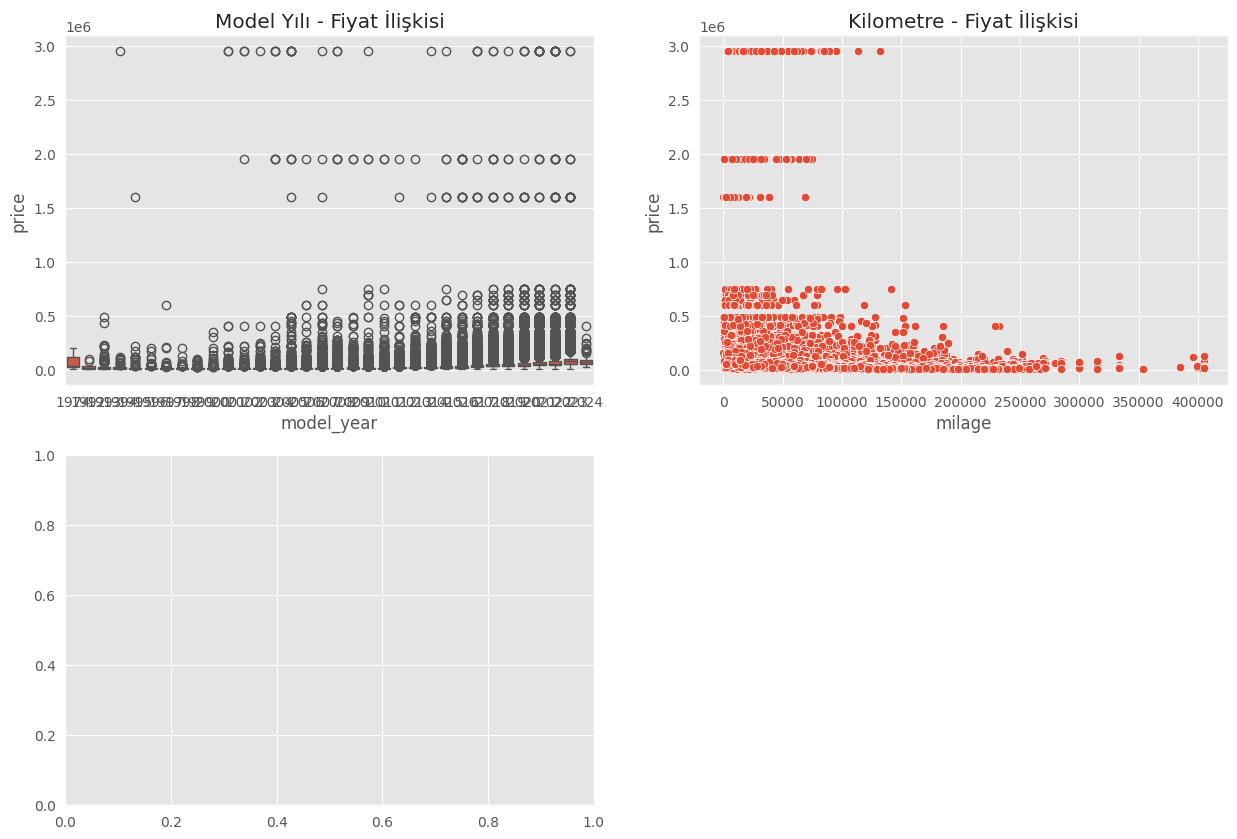

In [17]:
def main():
    print("\n" + "="*50)
    print("Araç Fiyat Tahmini Uygulamasına Hoş Geldiniz!")
    print("="*50)

    # Modeli yükle ve df'yi elde et
    model, df = get_model(), pd.read_csv('../dataset/train.csv')  # df'yi burada yükledik

    # Ekstra görselleştirmeler
    plot_extra_visualizations(df)

    # Model karşılaştırması
    compare_models(df)

    # Kullanıcı girişi ve tahmin
    while True:
        # Kullanıcı girişi al
        user_data = get_user_input()

        # Tahmin yap
        predicted_price = model.predict(user_data)[0]

        # Sonucu göster
        print("\n" + "="*50)
        print("TAHMİN SONUÇLARI")
        print("="*50)
        print(f"\nGirilen Araç Özellikleri:")
        print(f"- Marka: {user_data['brand'][0]}")
        print(f"- Model Yılı: {user_data['model_year'][0]} (Yaş: {user_data['age'][0]} yıl)")
        print(f"- Kilometre: {user_data['milage'][0]:,} km")
        print(f"- Yakıt Türü: {user_data['fuel_type'][0]}")
        print(f"- Motor Gücü: {user_data['engine_power'][0]} HP")
        print(f"- Motor Hacmi: {user_data['engine_volume'][0]} L")
        print(f"- Silindir Sayısı: {user_data['cylinders'][0]}")
        print(f"- Şanzıman Türü: {user_data['transmission_type'][0]}")
        print(f"- Kaza Geçmişi: {'Evet' if user_data['accident'][0] else 'Hayır'}")
        print(f"- Temiz Başlık: {'Evet' if user_data['clean_title'][0] else 'Hayır'}")

        print("\n" + "-"*50)
        print(f"\nTahmini Araç Fiyatı: ${predicted_price:,.2f}")
        print("-"*50)

        # Devam etmek isteyip istemediğini sor
        another = input("\nBaşka bir tahmin yapmak ister misiniz? (Evet/Hayır): ").lower()
        if another != 'evet':
            print("\nProgram sonlandırılıyor...")
            print("Görselleştirme dosyalarını kontrol etmeyi unutmayın!")
            break

if __name__ == "__main__":
    main()
